# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Seed

In [2]:
SEED=139
np.random.seed(SEED)

# Dataset

In [3]:
dataset = pd.read_csv('dataset/Mall_Customers.csv')
dataset.loc[dataset['Spending Score (1-100)'] <= 25, 'Category'] = 'low'
dataset.loc[(dataset['Spending Score (1-100)'] > 25) & (dataset['Spending Score (1-100)'] <= 50), 'Category'] = 'medium'
dataset.loc[dataset['Spending Score (1-100)'] > 50, 'Category'] = 'high'
print(dataset.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Category'],
      dtype='object')


In [4]:
dataset = dataset[['Age', 'Annual Income (k$)', 'Category']]
print(dataset.columns)

Index(['Age', 'Annual Income (k$)', 'Category'], dtype='object')


In [5]:
X = dataset[['Age', 'Annual Income (k$)']].to_numpy(np.float32)
Y = dataset[['Category']].to_numpy()
print(X)
print(Y)

[[ 19.  15.]
 [ 21.  15.]
 [ 20.  16.]
 [ 23.  16.]
 [ 31.  17.]
 [ 22.  17.]
 [ 35.  18.]
 [ 23.  18.]
 [ 64.  19.]
 [ 30.  19.]
 [ 67.  19.]
 [ 35.  19.]
 [ 58.  20.]
 [ 24.  20.]
 [ 37.  20.]
 [ 22.  20.]
 [ 35.  21.]
 [ 20.  21.]
 [ 52.  23.]
 [ 35.  23.]
 [ 35.  24.]
 [ 25.  24.]
 [ 46.  25.]
 [ 31.  25.]
 [ 54.  28.]
 [ 29.  28.]
 [ 45.  28.]
 [ 35.  28.]
 [ 40.  29.]
 [ 23.  29.]
 [ 60.  30.]
 [ 21.  30.]
 [ 53.  33.]
 [ 18.  33.]
 [ 49.  33.]
 [ 21.  33.]
 [ 42.  34.]
 [ 30.  34.]
 [ 36.  37.]
 [ 20.  37.]
 [ 65.  38.]
 [ 24.  38.]
 [ 48.  39.]
 [ 31.  39.]
 [ 49.  39.]
 [ 24.  39.]
 [ 50.  40.]
 [ 27.  40.]
 [ 29.  40.]
 [ 31.  40.]
 [ 49.  42.]
 [ 33.  42.]
 [ 31.  43.]
 [ 59.  43.]
 [ 50.  43.]
 [ 47.  43.]
 [ 51.  44.]
 [ 69.  44.]
 [ 27.  46.]
 [ 53.  46.]
 [ 70.  46.]
 [ 19.  46.]
 [ 67.  47.]
 [ 54.  47.]
 [ 63.  48.]
 [ 18.  48.]
 [ 43.  48.]
 [ 68.  48.]
 [ 19.  48.]
 [ 32.  48.]
 [ 70.  49.]
 [ 47.  49.]
 [ 60.  50.]
 [ 60.  50.]
 [ 59.  54.]
 [ 26.  54.]
 [ 45.  54.]

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, train_size=0.9, random_state=SEED)
Y_train = np.ravel(Y_train)
Y_test = np.ravel(Y_test)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print(Y_train.shape, Y_test.shape)

(180,) (20,)


# Training and Testing

In [7]:
def run(k, metric, show_confusion_matrix=False):
    model = KNeighborsClassifier(n_neighbors=k, metric=metric)
    model.fit(X_train, Y_train)
    
    Y_pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, Y_pred)
    
    if show_confusion_matrix:
        display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        display_cm.plot()
        plt.show()
    
    return accuracy_score(Y_test, Y_pred)

## Plotting K vs Accuracy

In [8]:
def plot_k_vs_accuracy(metric: str):
    ks = list(range(5, 31, 2))
    accuracies = []
    for k in ks:
        result = run(k, metric)
        accuracies.append(result)
        
    plt.title(f'K vs Accuracy With {metric.upper()} Distance Metric')
    plt.plot(ks, accuracies)
    plt.xlabel('Neigbour Count (K)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

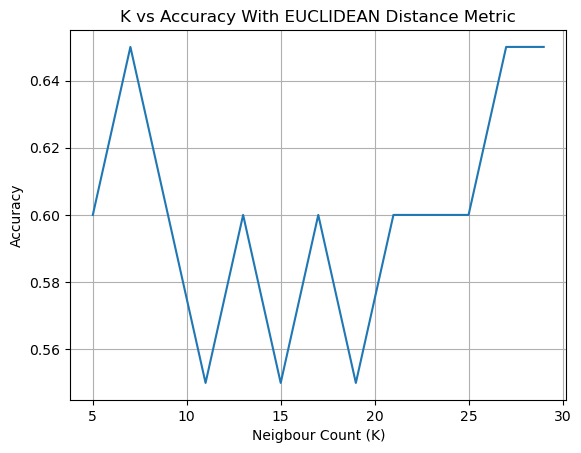

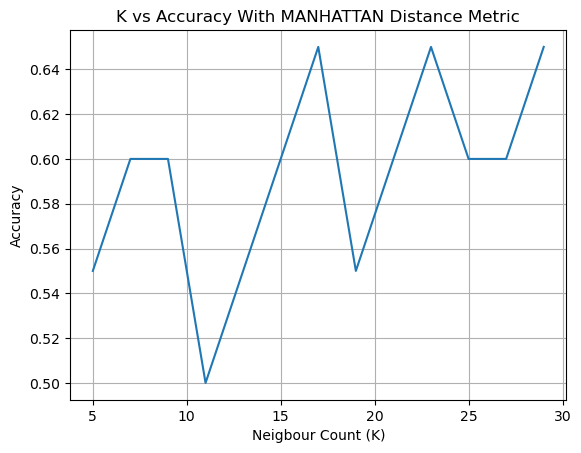

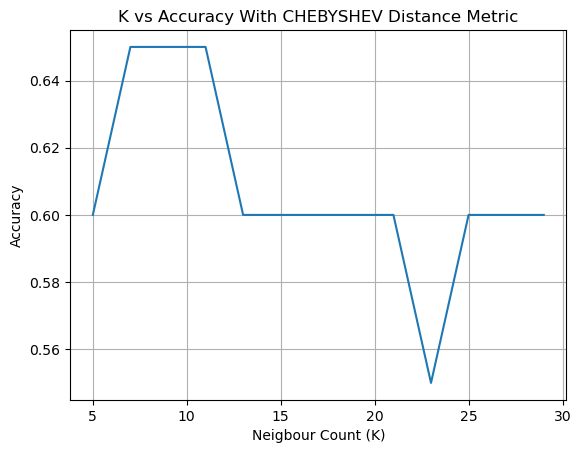

In [9]:
plot_k_vs_accuracy('euclidean')
plot_k_vs_accuracy('manhattan')
plot_k_vs_accuracy('chebyshev')

## Performance Difference With Different Metrics

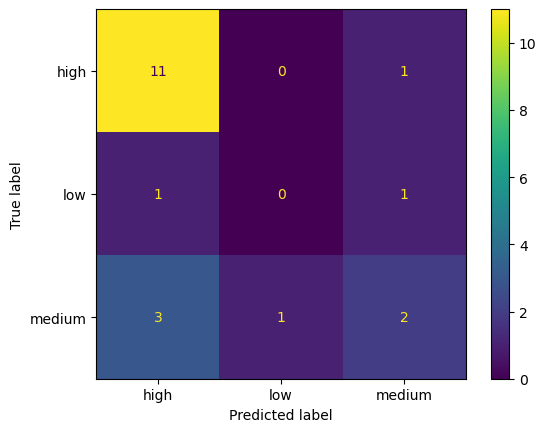

0.65

In [10]:
run(29, 'euclidean', True)

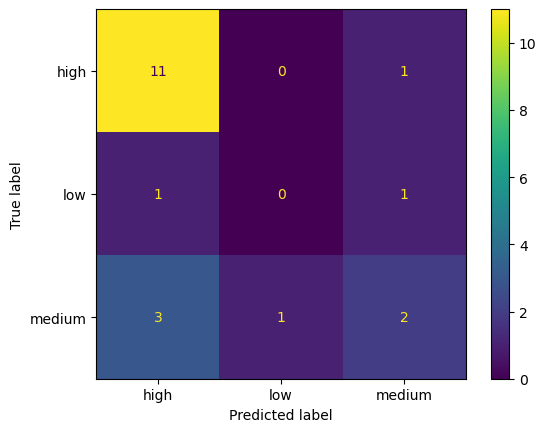

0.65

In [11]:
run(29, 'manhattan', True)

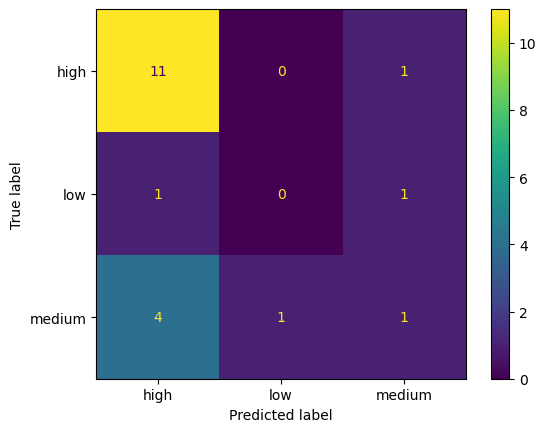

0.6

In [12]:
run(29, 'chebyshev', True)

# Results

- Unsupervised learning is a class of machine learning algorithm where a model/algorithm learns without explicitly labelled/annotated data.

- kNN or K-Nearest-Neighbors is a supervised machine learning algorithm that classifies a given input datum to given classes. It looks at classes the K nearest neighbors belong to and decides the best fitting class.

- Euclidean, Manhattan and Chebyshev distances are different distance metrics.
    - Euclidean distance is the standard distance used in various situations, defined as: 

        ```math.sqrt((x2 - x1)**2 + (y2 - y1)**2)```
    - Manhattan distance is a distance metric used in grid based algorithms, but is also applied in continous spaces. It is defined as:

        ```abs(x2 - x1) + abs(y2 - y1)```
    - Chebyshev distance is a simplified version of the Manhattan distance, defined as:
    
        ```math.max((y2 - y1), (x2 - x1))```

From the experiments that were ran, it seems a K value of ~29 gave the best results.

High and medium get misclassified the most, maybe because higher spending scores depend on more features than just age and annual income.

As for the decision boundaries, the following code can visualise:

In [43]:
def plot_decision_boundary(metric):
    model = KNeighborsClassifier(n_neighbors=29, metric=metric)
    model.fit(X_train, Y_train)
    
    age_min, age_max = X_train[..., 0].min() - 1, X_train[..., 0].max() + 1
    income_min, income_max = (
        X_train[..., 1].min() - 1,
        X_train[..., 1].max() + 1
    )

    xx, yy = np.meshgrid(
        np.arange(age_min, age_max, 0.1),
        np.arange(income_min, income_max, 0.1)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    category_map = {
        'low': 0,
        'medium': 1,
        'high': 2
    }
    Z = model.predict(grid)
    Z = pd.Series(Z).map(category_map).to_numpy()
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(
        X_train[..., 0],
        X_train[..., 1],
        c=pd.Series(np.ravel(Y_train)).map({'low': 0.0, 'medium': 1.0, 'high': 2.0}).to_numpy(np.float32),
        edgecolor='black'
    )

    plt.xlabel('Age')
    plt.ylabel('Annual Income (k$)')
    plt.title('KNN Decision Boundary (K=17, Euclidean)')
    plt.show()

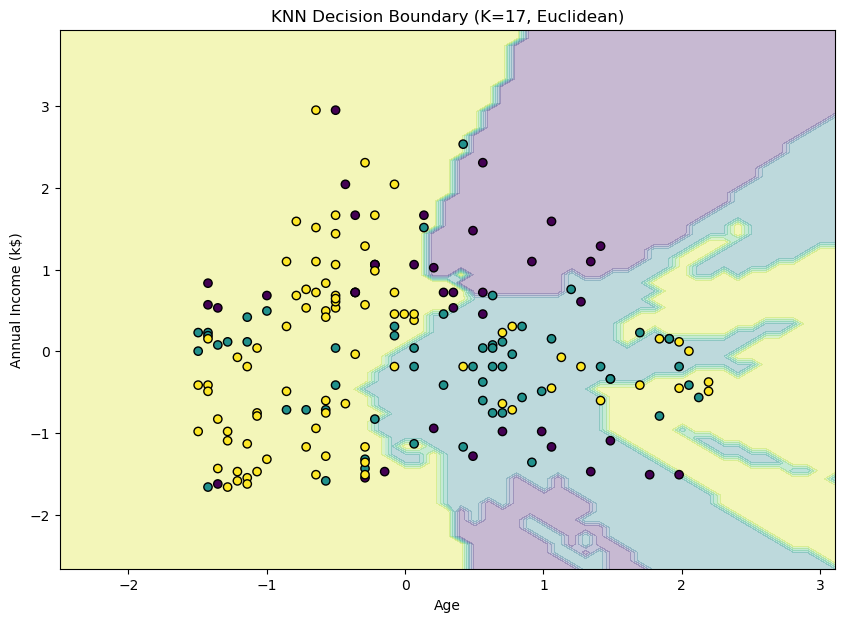

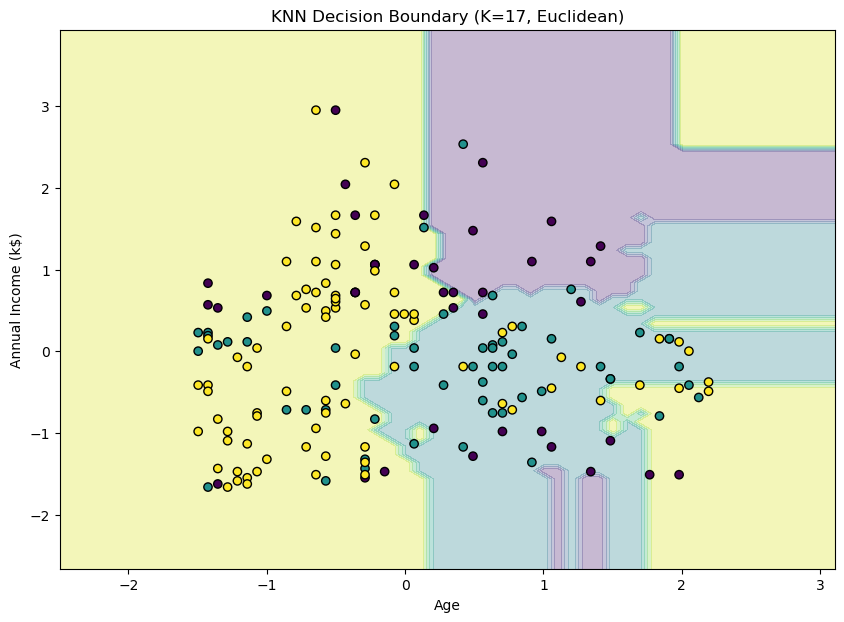

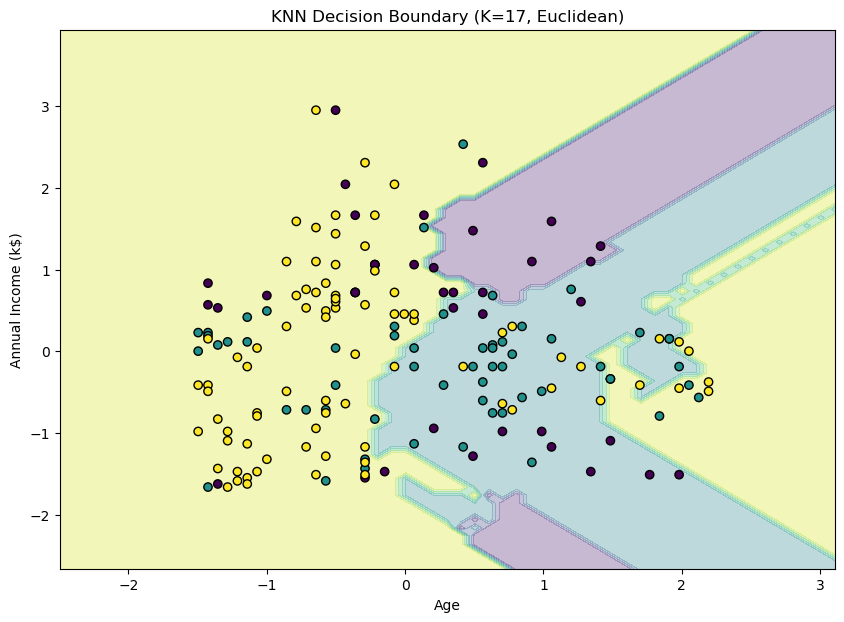

In [44]:
plot_decision_boundary('euclidean')
plot_decision_boundary('manhattan')
plot_decision_boundary('chebyshev')